# Project 3: Multi-Agent Reinforcement Learning

### Group number
### Anton Mlynczyk - 1007283226
### Osman Sultan - 1006803014
### Sunghoo (Kevin) Kim - 1006820013
### Gaeun (Grace) Yim - 1011904824

Please read all instructions carefully before attempting each part of the problem. Each team only needs to have one submission with all the names of team-members and group number at the beginning of the jupyter notebook.

The jupyter notebook should contain your code, discussions, derivations, analysis and relevant figures. Make sure the code, plots and videos shown in your file can be reproduce when I rerun the code in grading. Feel free to add or move Cells.

In this project, you will implement three different multi-agent reinforcement learning algorithms to solve a navi-
gation problem involving two agents and then compare the results.

### 1. The Invader-Defender Game [10 Marks]

The task you will be implementing for this assignment is defined as follow:

- Time is broken up into discrete epochs.
- The world is a square area that is broken up into a 6-by-6 grid of cells.
- There are two players or agents; both of them can move up, down, left, or right. At each time step, both players take their action simultaneously. Each cannot see the others' action at that time step, but the state of the system and previous actions are fully observable to each. If the chosen action takes an agent outside of the grid, then the agent remains in the current position.
- The invader, marked I, starts in the upper-left corner of the world. The defender, marked D, starts in the bottom-left corner of the world.
- The 9 cells centered around the defender's current position (see Figure 1), is the region where the invader has a 90% chance of beign captured. The game ends whenever the invader is captured by the defender, or the invader enters the fixed territory cell marked T, whichever comes first. The discount factor for future rewards is $\gamma = 0.95$.
- The goal of the defender is to capture the invader as far away as possible from the territory T. The goal of the invader is to move as close as possible to the territory T before being captured.


1.1 Explain how you would model this problem as a stochastic game: [10 Marks]

   (a) What is the state space, and what are the action spaces for each agent?

   State Space: Position on the grid of both agents. State: ((p1_loc), (p2_loc)) (e.g) -> ((0, 0), (1, 1))

   Action Space (for each agent): Left, Right, Up, Down

   (b) Describe the transition probability matrix for this stochastic game.

   The matrix is a 6^4 x 6^4 grid that denotes the probability of transitioning from one state to another. It has this dimension because each has 36 (6^2) possible positions that it can exist in, and each state models the position of both agents. However, most of entries within the matrix are zero since each agent can only move to its adjacent states within the board with equal probability. 

   (c) Which states, if any, are terminal states?

   One clear terminal state is when the Invader reaches the Goal (T).

   There are several other terminal states based on the location of the Defender and whether the game terminates with 90% probabiliy. For each location that the Defender is in on the 6x6 grid, if the Invader is within the surrounding 3x3 grid, there is a 90% probability that the game terminates (the Defender captures the Invader) in given state (which includes the position of both the defender and invader).
    
   (d) Derive one suitable reward function that allows the defender to achieve the goal for this task. Derive one suitable reward function that allows the invader to achieve the goal for this task. Are these the only possible suitable reward functions? Why or why not? What is the relationship between the defender's and invader's reward functions? Choosing a good reward function is critical to get good results in RL, so please choose carefully.

   Non-terminal
   Invader: (Negative Manhattan Distance between Invader & Goal) + (Positive Manhattan Distance between Invader & Defender) 
   Defender: (Positive Manhattan Distance between Invader & Goal) + (Negative Manhattan Distance between Invader & Defender) 

   Terminal:
   If Captured:
   Invader: Negative Manhattan Distance between Invader & Goal; Defender: Positive Manhattan Distance between Invader & Goal

   If Invader reach goal:
   Invader: +10; Defender: -10
    
   (e) What kind of stochastic game is this (e.g. what special properties does it possess based on what you have learned about stochastic games)?

   Two-player Zero-sum Stoachstic Game with Simultaneous Actions

   The reward must add up to 0 for each joint action.

1.2 Now, you are asked to implement the behavior of the invader/defender domain in a Python code. Create a
python class called InvaderDefenderEnv. Here, you should create functions similar to what you have done
in Projects 1 and 2, but for the stochastic game. In particular, you would want to consider functions to:
return a list of possible states in the game; given a state, check if it is terminal; given a transition, return its
probability of occurring and the immediate reward (these should be consistent with your answers to part 1 of
the question); and given a state and actions of the agents, return the next state of the game (to simulate the
task behavior for Q-learning) [10 Marks]


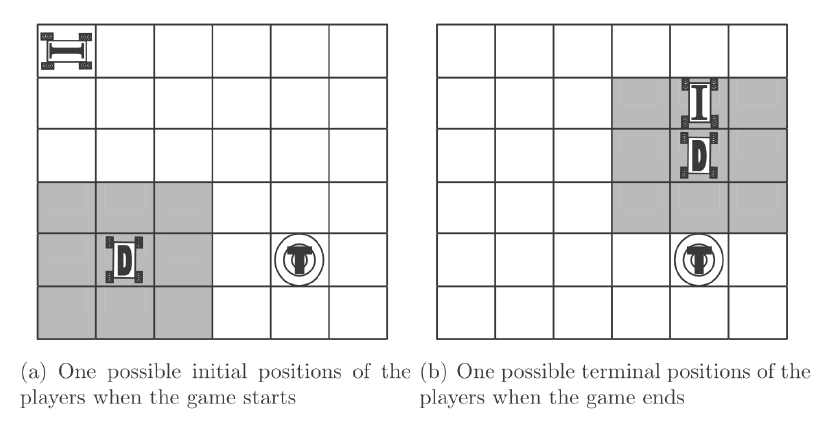

In [1]:
import numpy as np

In [9]:
class InvaderDefenderEnv:
    def __init__(self):
        self.grid_size = 6
        self.territory_pos = (4, 4)  # Fixed territory position
        self.invader_pos = (0, 0)     # Initial invader position
        self.defender_pos = (5, 0)    # Initial defender position
        self.actions = ['up', 'down', 'left', 'right']
        self.action_effects = {
            'up': (-1, 0),
            'down': (1, 0),
            'left': (0, -1),
            'right': (0, 1)
        }

    def get_all_states(self):
        """Return all possible states as tuples of (invader_pos, defender_pos)."""
        states = []
        for i_x in range(self.grid_size):
            for i_y in range(self.grid_size):
                for d_x in range(self.grid_size):
                    for d_y in range(self.grid_size):
                        states.append(((i_x, i_y), (d_x, d_y)))
        return states
    
    def is_terminal(self, state):
        """Check if the state is terminal (invader reached T)."""
        invader_pos, _ = state
        return invader_pos == self.territory_pos
    
    def _move_agent(self, pos, action):
        """Move an agent, clipping to grid boundaries."""
        dx, dy = self.action_effects[action]
        new_x = np.clip(pos[0] + dx, 0, self.grid_size - 1)
        new_y = np.clip(pos[1] + dy, 0, self.grid_size - 1)
        return (new_x, new_y)
    
    def _is_in_defender_area(self, invader_pos, defender_pos):
        """Check if invader is within defender's 3x3 area."""
        d_x, d_y = defender_pos
        i_x, i_y = invader_pos
        return (d_x - 1 <= i_x <= d_x + 1) and (d_y - 1 <= i_y <= d_y + 1)
    
    def _manhattan_distance(self, pos1, pos2):
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])
    
    def get_transition_info(self, state, invader_action, defender_action):
        """
        Return list of (probability, next_state, invader_reward, defender_reward, done).
        """
        invader_pos, defender_pos = state
        transitions = []

        if self.is_terminal(state):
            transitions.append((1.0, state, 0, 0, True))
            return transitions

        # Check if invader is in defender's 3x3 area
        in_defender_area = self._is_in_defender_area(invader_pos, defender_pos)

        if in_defender_area:
            # 90% chance of capture (game ends immediately)
            capture_distance = self._manhattan_distance(invader_pos, self.territory_pos)
            transitions.append((
                0.9,
                state,  # No movement
                -capture_distance,  # Invader reward
                capture_distance,   # Defender reward
                True
            ))

            # 10% chance: both agents move
            new_i_pos = self._move_agent(invader_pos, invader_action)
            new_d_pos = self._move_agent(defender_pos, defender_action)
            new_state = (new_i_pos, new_d_pos)
            if new_i_pos == self.territory_pos:
                # Invader reached T
                transitions.append((0.1, new_state, 10, -10, True))
            else:
                # Non-terminal reward
                distance_to_T = self._manhattan_distance(new_i_pos, self.territory_pos)
                distance_to_defender = self._manhattan_distance(new_i_pos, new_d_pos)
                invader_reward = -distance_to_T + distance_to_defender
                defender_reward = distance_to_T - distance_to_defender
                transitions.append((0.1, new_state, invader_reward, defender_reward, False))
        else:
            # No capture chance
            new_i_pos = self._move_agent(invader_pos, invader_action)
            new_d_pos = self._move_agent(defender_pos, defender_action)
            new_state = (new_i_pos, new_d_pos)
            if new_i_pos == self.territory_pos:
                transitions.append((1.0, new_state, 10, -10, True))
            else:
                distance_to_T = self._manhattan_distance(new_i_pos, self.territory_pos)
                distance_to_defender = self._manhattan_distance(new_i_pos, new_d_pos)
                invader_reward = -distance_to_T + distance_to_defender
                defender_reward = distance_to_T - distance_to_defender
                transitions.append((1.0, new_state, invader_reward, defender_reward, False))

        return transitions
    
    def step(self, invader_action, defender_action):
        """Simulate one step with given actions. Returns next_state, rewards, done"""
        transitions = self.get_transition_info(
            (self.invader_pos, self.defender_pos),
            invader_action,
            defender_action
        )
        # Sample a transition based on probabilities
        probs = [t[0] for t in transitions]
        chosen_idx = np.random.choice(len(transitions), p=probs)
        prob, next_state, invader_r, defender_r, done = transitions[chosen_idx]
        self.invader_pos, self.defender_pos = next_state
        return next_state, (invader_r, defender_r), done
    
    def reset(self):
        """Reset to initial positions."""
        self.invader_pos = (0, 0)
        self.defender_pos = (5, 0)
        return (self.invader_pos, self.defender_pos)
    


In [38]:
import unittest

class TestInvaderDefenderEnv(unittest.TestCase):
    def setUp(self):
        self.env = InvaderDefenderEnv()
        self.env.reset()

    # --------------------------
    # Test Helper Methods
    # --------------------------
    def test_move_agent(self):
        # Test movement within bounds
        self.assertEqual(self.env._move_agent((3, 3), 'up'), (2, 3))
        self.assertEqual(self.env._move_agent((3, 3), 'left'), (3, 2))

        # Test boundary clamping
        self.assertEqual(self.env._move_agent((0, 0), 'up'), (0, 0))  # Can't move up
        self.assertEqual(self.env._move_agent((5, 5), 'right'), (5, 5))  # Can't move right

    def test_is_in_defender_area(self):
        # Defender at (3,3)
        self.assertTrue(self.env._is_in_defender_area((3,3), (3,3)))  # Same cell
        self.assertTrue(self.env._is_in_defender_area((2,2), (3,3)))  # Top-left corner of 3x3
        self.assertFalse(self.env._is_in_defender_area((1,3), (3,3)))  # Outside 3x3
        self.assertFalse(self.env._is_in_defender_area((0,0), (3,3)))  # Outside 3x3
        self.assertTrue(self.env._is_in_defender_area((4,4), (5,5)))  # right corner

    # --------------------------
    # Test State Management
    # --------------------------
    def test_terminal_state_detection(self):
        # Non-terminal state
        self.assertFalse(self.env.is_terminal(((0,0), (5,0))))

        # Terminal state (invader at T)
        self.assertTrue(self.env.is_terminal(((4,4), (3,3))))

    def test_reset(self):
        self.env.invader_pos = (3,3)
        self.env.defender_pos = (2,2)
        self.env.reset()
        self.assertEqual(self.env.invader_pos, (0,0))
        self.assertEqual(self.env.defender_pos, (5,0))

    # --------------------------
    # Test Transitions & Rewards
    # --------------------------
    def test_capture_transition(self):
        # Force invader into defender's area
        state = ((3,3), (3,3))  # Invader at defender's position
        transitions = self.env.get_transition_info(state, 'up', 'down')

        # Should have 2 transitions: 90% capture, 10% movement
        self.assertEqual(len(transitions), 2)
        
        # Check capture reward
        capture_reward = self.env._manhattan_distance((3,3), self.env.territory_pos)
        self.assertEqual(transitions[0][2], -capture_reward)  # Invader reward
        self.assertEqual(transitions[0][3], capture_reward)   # Defender reward

    def test_goal_reached_transition(self):
        # Invader one step away from T
        state = ((4,3), (5,0))
        transitions = self.env.get_transition_info(state, 'right', 'up')

        # Next state should be terminal with +10/-10 rewards
        self.assertEqual(transitions[0][1], ((4,4), (4,0)))
        self.assertEqual(transitions[0][2], 10)  # Invader
        self.assertEqual(transitions[0][3], -10) # Defender

    def test_edge_case_movement(self):
        # Defender at edge of grid (5,0) tries to move down
        state = ((0,0), (5,0))
        transitions = self.env.get_transition_info(state, 'down', 'down')

        # Defender should stay at (5,0) due to boundary
        new_defender_pos = transitions[0][1][1]
        self.assertEqual(new_defender_pos, (5,0))

    # --------------------------
    # Test Step Function
    # --------------------------
    def test_step_termination(self):
        # Force invader to T in one step
        self.env.step('right', 'down')  # Irrelevant defender action
        self.env.step('right', 'down')  # Repeat until T is reached
        self.env.step('right', 'down')  # Irrelevant defender action
        self.env.step('right', 'down')  # Repeat until T is reached
        self.env.step('down', 'down')  # Irrelevant defender action
        self.env.step('down', 'down')  # Repeat until T is reached
        self.env.step('down', 'down')  # Irrelevant defender action
        self.env.step('down', 'down')  # Repeat until T is reached

        # After reaching T, further steps should do nothing
        _, rewards, done = self.env.step('up', 'up')
        self.assertTrue(done)
        self.assertEqual(rewards, (0, 0))

    def test_probabilistic_capture(self):
        # Test capture probability distribution
        state = ((3,3), (3,3))
        self.env.invader_pos, self.env.defender_pos = state
        
        # Simulate 1000 steps and count terminations
        captures = 0
        for _ in range(1000):
            self.env.reset()
            self.env.invader_pos, self.env.defender_pos = state
            _, _, done = self.env.step('up', 'up')
            if done:
                captures += 1
        print(captures / 1000)
        # Check if ~90% captures (allow small tolerance)
        self.assertAlmostEqual(captures / 1000, 0.9, delta=0.05)

In [36]:
test_suite = unittest.TestLoader().loadTestsFromTestCase(TestInvaderDefenderEnv)

# Run tests and print output
unittest.TextTestRunner(verbosity=2).run(test_suite)

test_capture_transition (__main__.TestInvaderDefenderEnv.test_capture_transition) ... ok
test_edge_case_movement (__main__.TestInvaderDefenderEnv.test_edge_case_movement) ... ok
test_goal_reached_transition (__main__.TestInvaderDefenderEnv.test_goal_reached_transition) ... ok
test_is_in_defender_area (__main__.TestInvaderDefenderEnv.test_is_in_defender_area) ... ok
test_move_agent (__main__.TestInvaderDefenderEnv.test_move_agent) ... ok
test_probabilistic_capture (__main__.TestInvaderDefenderEnv.test_probabilistic_capture) ... ok
test_reset (__main__.TestInvaderDefenderEnv.test_reset) ... ok
test_step_termination (__main__.TestInvaderDefenderEnv.test_step_termination) ... ok
test_terminal_state_detection (__main__.TestInvaderDefenderEnv.test_terminal_state_detection) ... ok

----------------------------------------------------------------------
Ran 9 tests in 0.269s

OK


<unittest.runner.TextTestResult run=9 errors=0 failures=0>

### 2. Multi-agent Reinforcement Learning [60 Marks]

Now that you have defined the environment needed to perform optimization, you are next asked to implement three
of the standard multi-agent reinforcement learning algorithms you have learned in this course.

2.1. Distributed Q-learning. [20 points]

2.2. Shapley Value Iteration. [20 points]

2.3. MiniMax Q-learning. [20 points]

For MiniMax Q-learning, you should train the algorithm for both agents and sample each agent's own policy to
test them. Investigate whether running the trained policy for both agents would lead to the coordination issue in
the MiniMax Q-learning algorithm.

You can implement each algorithm in a seperate Python function or class. Also, your implementation must have
a train function to run your experiment. Here, you will have to initialize your domain, and the algorithm with your
parameter settings, and run your algorithm.

For each of the three algorithms:

(a) set the value function or Q-values initially to zeros.

(b) for solving an LP, you should use the scipy package (in this case, make sure you are correctly inputting the bounds).

(c) for Q-learning, fix the episode length for training and testing to T = 200.

(d) the number of episodes can be adjusted to obtain convergence as you see necessary; for value iteration, you can stop updates when the maximum difference in value functions between two iterations drops below $10^{-6}$. For Q-learning based methods, you have to define the number episodes required for converge. A criteria for setting up the number of episodes can be maximum difference in value functions. Your criteria should be explained in the project.

(e) in this project, we are giving you full control to experiment with hyper-parameters that you think work well overall (e.g. learning rate, $\epsilon$), but please be consistent in your choice across algorithms.

(f) for all algorithms, testing should be done using the greedy policy on separate rollouts (trajectories) at the end of each training episode.

For each algorithm, you should report the following:

I. a table containing hyper-parameter values you used in your experiments.

II. plots of the training and testing performance over time as a function of the number of training episodes already performed (for value iteration, your training performance can be the error in V between iterations. For algorithms with a Q function training performance over time can be the difference between new and old Q functions. Testing performance over time can be total reward per episode).

III. 2D heat-maps showing: (1) the final value function from the invader's perspective as a function of the invader's starting position, when the defender starting position is fixed at x = 0, y = 5, and (2) the final value function from the defender's perspective as a function of the defender's starting position when the invader's starting position is fixed at x = 0, y = 0.

IV. a pictorial representation (you may include a drawing based on the output of your code) of the agents' motion in the grid during a typical testing episode once the algorithm has converged.

### 3. Results discussion [30 Marks]

In your report, please provide details about the results of your experiment. Include all relevant plots to support
your answers:

3.1. Did your algorithms converge? How many iterations did they take?     [5 Marks]

3.2. What were the final policies? Do the final policies agree between value iteration and Q-learning? What do
you think could explain the differences between them, if any? [5 Marks]

3.3 Looking at the final policy you obtained, were there any states in which the optimal mini-max equilibrium was
non-deterministic (that is, either defender or invader or both agents take action randomly)? Please include a
list of all such states in your report. Do you think this result is expected? Why or why not?. [5 Marks]

3.4 Based on your heat-map plots, for which initial states does the invader win and defender lose (e.g. the invader
makes it to the territory and evades capture)? Similarly, for which initial states does the defender win and
invader lose (e.g. the invader is captured before reaching the territory)? Are there any starting states in which
it is not clear whether invader and defender will win the game? Explain. [10 Marks]

3.5.Which algorithm did you feel was more reliable for solving this task? Which algorithm would be more efficient
if the state space was considerably larger?.[5 Marks]